## Аналіз A/B-тестів

Ви - аналітик даних в ІТ-компанії і до вас надійшла задача проаналізувати дані A/B тесту в популярній [грі Cookie Cats](https://www.facebook.com/cookiecatsgame). Це - гра-головоломка в стилі «з’єднай три», де гравець повинен з’єднати плитки одного кольору, щоб очистити дошку та виграти рівень. На дошці також зображені співаючі котики :)

Під час проходження гри гравці стикаються з воротами, які змушують їх чекати деякий час, перш ніж вони зможуть прогресувати або зробити покупку в додатку.

У цьому блоці завдань ми проаналізуємо результати A/B тесту, коли перші ворота в Cookie Cats було переміщено з рівня 30 на рівень 40. Зокрема, ми хочемо зрозуміти, як це вплинуло на утримання (retention) гравців. Тобто хочемо зрозуміти, чи переміщення воріт на 10 рівнів пізніше якимось чином вплинуло на те, що користувачі перестають грати в гру раніше чи пізніше з точки зору кількості їх днів з моменту встановлення гри.

Будемо працювати з даними з файлу `cookie_cats.csv`. Колонки в даних наступні:

- `userid` - унікальний номер, який ідентифікує кожного гравця.
- `version` - чи потрапив гравець в контрольну групу (gate_30 - ворота на 30 рівні) чи тестову групу (gate_40 - ворота на 40 рівні).
- `sum_gamerounds` - кількість ігрових раундів, зіграних гравцем протягом першого тижня після встановлення
- `retention_1` - чи через 1 день після встановлення гравець повернувся і почав грати?
- `retention_7` - чи через 7 днів після встановлення гравець повернувся і почав грати?

Коли гравець встановлював гру, його випадковим чином призначали до групи gate_30 або gate_40.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats import weightstats as stests
import statsmodels.stats.api as sms
from math import ceil
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

1. Для початку, уявімо, що ми тільки плануємо проведення зазначеного А/B-тесту і хочемо зрозуміти, дані про скількох користувачів нам треба зібрати, аби досягнути відчутного ефекту. Відчутним ефектом ми вважатимемо збільшення утримання на 1% після внесення зміни. Обчисліть, скільки користувачів сумарно нам треба аби досягнути такого ефекту, якщо продакт менеджер нам повідомив, що базове утримання є 19%.

In [2]:
effect_size = sms.proportion_effectsize(0.20, 0.19)      # Розрахунок розміру ефекту на основі наших очікуваних показників
required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,
    alpha=0.05,                                          # Стандартне припущення
    ratio=1
    )  
required_n = ceil(required_n)                            # Округлення до наступного цілого числа
total_n = required_n * 2

print('Оскільки в умові рівень значущості не вказано, приймаємо стандартне значення α = 0.05')
print(f'Для проведення зазначеного А/B-тесту і досягнення збільшення утримання на 1% потрібно сумарно {total_n } користувачів,')
print(f'тобто по {required_n} користувачів у кожній групі')

Оскільки в умові рівень значущості не вказано, приймаємо стандартне значення α = 0.05
Для проведення зазначеного А/B-тесту і досягнення збільшення утримання на 1% потрібно сумарно 49276 користувачів,
тобто по 24638 користувачів у кожній групі


2. Зчитайте дані АВ тесту у змінну `df` та виведіть середнє значення показника показник `retention_7` (утримання на 7 день) по версіям гри. Сформулюйте гіпотезу: яка версія дає краще утримання через 7 днів після встановлення гри?

In [3]:
df = pd.read_csv('../data/cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
pd.crosstab(df['version'], df['retention_7'])

retention_7,False,True
version,,
gate_30,36198,8502
gate_40,37210,8279


In [5]:
retention_rates = df.groupby('version')['retention_7']
retention_rates = retention_rates.agg(['mean', 'std', stats.sem])
retention_rates.columns = ['retention', 'std_deviation', 'std_error']

retention_rates.style.format('{:.5f}')

,retention,std_deviation,std_error
version,,,
gate_30,0.19020,0.39246,0.00186
gate_40,0.18200,0.38585,0.00181


Судячи зі статистики вище, **gate_30** дає краще утримання, прибл. retention rate `19,02%` проти `18,20%`.

Нанесення даних на графік спростить розуміння цих результатів:

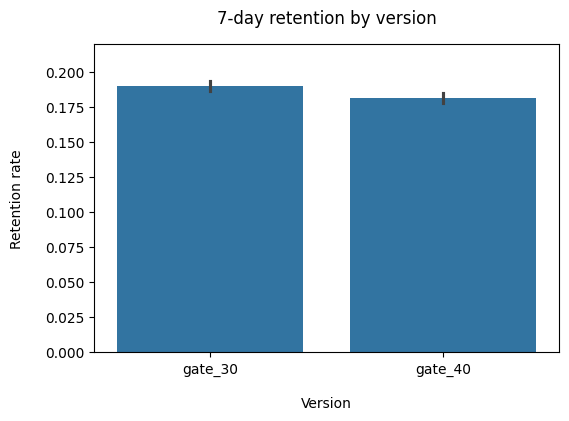

In [6]:
plt.figure(figsize=(6,4))

sns.barplot(x=df['version'], y=df['retention_7'])

plt.ylim(0, 0.22)
plt.title('7-day retention by version', pad=15)
plt.xlabel('Version', labelpad=15)
plt.ylabel('Retention rate', labelpad=15);

Середнє значення `retention_7` показало, що у групі **gate_30** рівень утримання через 7 днів становить **19.02%**, а у групі **gate_40** — **18.20%**.

Отже, **попередньо** версія **gate_30** демонструє краще утримання користувачів. Проте для остаточного висновку потрібно перевірити, чи є ця різниця статистично значущою.

**Гіпотези:**
- **H0:** рівень утримання через 7 днів у групах `gate_30` і `gate_40` однаковий.
- **H1:** рівень утримання через 7 днів у групах `gate_30` і `gate_40` відрізняється.

3. Перевірте з допомогою пасуючого варіанту z-тесту, чи дає якась з версій гри кращий показник `retention_7` на рівні значущості 0.05. Обчисліть також довірчі інтервали для варіантів до переміщення воріт і після. Виведіть результат у форматі:

    ```
    z statistic: ...
    p-value: ...
    Довірчий інтервал 95% для групи control: [..., ...]
    Довірчий інтервал 95% для групи treatment: [..., ...]
    ```

    де замість `...` - обчислені значення.
    
    В якості висновку дайте відповідь на два питання:  

      1. Чи є статистична значущою різниця між поведінкою користувачів у різних версіях гри?   
      2. Чи перетинаються довірчі інтервали утримання користувачів з різних версій гри? Про що це каже?  


In [7]:
# control = до змін, treatment = після змін
control_results = df[df['version'] == 'gate_30']['retention_7']
treatment_results = df[df['version'] == 'gate_40']['retention_7']

# кількість успіхів і кількість спостережень
n_con = control_results.count()
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

# z-test для двох пропорцій
z_stat, pval = proportions_ztest(successes, nobs=nobs)

# 95% довірчі інтервали
lower, upper = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f'z statistic: {z_stat:.3f}')
print(f'p-value: {pval:.4f}')
print(f'Довірчий інтервал 95% для групи control: [{lower[0]:.3f}, {upper[0]:.3f}]')
print(f'Довірчий інтервал 95% для групи treatment: [{lower[1]:.3f}, {upper[1]:.3f}]')

z statistic: 3.164
p-value: 0.0016
Довірчий інтервал 95% для групи control: [0.187, 0.194]
Довірчий інтервал 95% для групи treatment: [0.178, 0.186]


**Висновок**

За результатами z-тесту отримано **p-value = 0.0016**, що менше за рівень значущості **0.05**.  
Отже, ми **відхиляємо Н0** і робимо висновок, що між групами є **статистично значуща різниця** у показнику `retention_7`.

Група **control** (`gate_30`) має вищий рівень утримання, ніж група **treatment** (`gate_40`): **19.02%** проти **18.20%**.

**95% довірчі інтервали:**
- control: **[0.187, 0.194]**
- treatment: **[0.178, 0.186]**

Довірчі інтервали **не перетинаються**, що також свідчить на користь того, що різниця між групами є реальною, а не випадковою.

Отже, перенесення воріт з 30-го на 40-й рівень не покращило утримання користувачів, а навпаки пов’язане зі зниженням `retention_7`.

4. Виконайте тест Хі-квадрат на рівні значущості 5% аби визначити, чи є залежність між версією гри та утриманням гравця на 7ий день після реєстрації.

    - Напишіть, як для цього тесту будуть сформульовані гіпотези.
    - Проведіть обчислення, виведіть p-значення і напишіть висновок за результатами тесту.


In [8]:
pd.crosstab(df['version'], df['retention_7'])

retention_7,False,True
version,,
gate_30,36198,8502
gate_40,37210,8279


In [9]:
crosstab = pd.crosstab(df['version'], df['retention_7'])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

print(f"χ² = {chi2:.3f}")
print(f"p-value = {p:.5f}")
print(f"Ступені свободи = {dof}")
print("Очікувані частоти:\n", expected)

χ² = 9.959
p-value = 0.00160
Ступені свободи = 1
Очікувані частоти:
 [[36382.90257127  8317.09742873]
 [37025.09742873  8463.90257127]]


**Гіпотези:** 
- **H0:** версія гри та утримання на 7-й день (`retention_7`) є незалежними, тобто зв’язку між ними немає.  
- **H1:** між версією гри та утриманням на 7-й день (`retention_7`) є залежність.

За результатами тесту χ² отримано **p-value = 0.00160**, що менше за рівень значущості **0.05**.  

Отже, **нульову гіпотезу відхиляємо**. Це означає, що між **версією гри** та **утриманням користувачів на 7-й день** є **статистично значуща залежність**.

Результат узгоджується з попереднім **z-тестом для двох пропорцій**, де також було отримано статистично значущу різницю. Це очікувано, оскільки для 2 груп з бінарною ознакою обидва підходи дають дуже схожі результати.

Практично це означає, що версія **gate_30** пов’язана з вищим рівнем утримання користувачів порівняно з **gate_40**.

________________________________________________________________________________________________________________________________________
**Time spent:** 1.5 hours

**What I learned:**
- розібралась із основними кроками аналізу **A/B-тесту**: від попереднього порівняння груп до статистичної перевірки гіпотез;
- навчилась правильно формулювати **H0** та **H1** для A/B-тестів;
- закріпила, як інтерпретувати **p-value**, рівень значущості **α** та довірчі інтервали;
- зрозуміла, як перевіряти різницю між двома пропорціями за допомогою **z-test**;
- попрактикувала **χ²-тест** і побачила, що для бінарних даних у 2 групах він дає узгоджений результат із z-тестом;
- закріпила послідовність аналізу в Python: підготовка даних, групування, візуалізація, тестування гіпотез і формулювання висновків.